In [ ]:
!unzip Brain_Cancer_MRI.zip

Streaming output truncated to the last 5000 lines.
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1003.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1004.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1005.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1006.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1007.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1008.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1009.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1010.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1011.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1012.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1013.jpg  
  inflating: Brain Cancer -  MRI dataset/brain_glioma/brain_glioma_1014.jpg  
  inflating: 

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:

# Define dataset path
DATASET_PATH = "/content/Brain Cancer -  MRI dataset"  # Update this with your dataset directory
CATEGORIES = ["brain_glioma", "brain_menin", "brain_tumor"]  # Folder names in dataset

# Image dimensions
IMG_SIZE = 64  # Resize images to 64x64 for CNN compatibility


In [ ]:
# Load images and labels
def load_data():
    images, labels = [], []
    for label, category in enumerate(CATEGORIES):
        folder_path = os.path.join(DATASET_PATH, category)
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to IMG_SIZE x IMG_SIZE
            images.append(img)
            labels.append(label)

    images = np.array(images) / 255.0  # Normalize images (0-255 → 0-1)
    labels = np.array(labels)
    return images, labels

# Load dataset
X, y = load_data()


In [ ]:
# Reshape X to fit the model (add channel dimension)
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# One-hot encode labels
y = to_categorical(y, num_classes=len(CATEGORIES))


In [ ]:
# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


In [ ]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


In [ ]:
# Check dataset distribution
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 4800, Val: 600, Test: 600


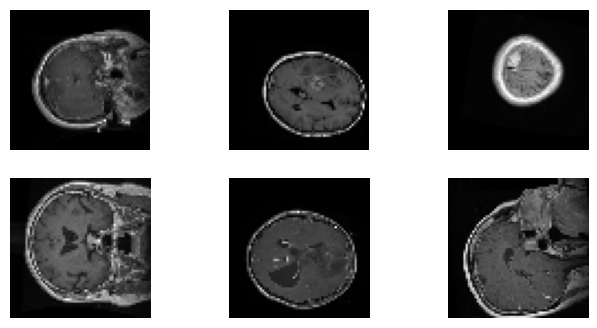

In [ ]:
# Plot sample images
plt.figure(figsize=(8, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.axis('off')
plt.show()


In [ ]:
# Define CNN Model
def build_cnn_model(input_shape=(64, 64, 1), num_classes=3):
    model = Sequential([
        # First Conv Layer
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),

        # Second Conv Layer
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Third Conv Layer
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Flatten and Fully Connected Layers
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')  # Output layer
    ])
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Build the CNN model
model = build_cnn_model()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Save Model
model.save('brain_tumor_vgg16.h5')


In [ ]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,011 (2.61 MB)

 Trainable params: 683,011 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Model
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


150/150 ━━━━━━━━━━━━━━━━━━━━ 35s 217ms/step - accuracy: 0.4175 - loss: 1.0487 - val_accuracy: 0.6233 - val_loss: 0.8331
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 213ms/step - accuracy: 0.6468 - loss: 0.7855 - val_accuracy: 0.7133 - val_loss: 0.6891
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 204ms/step - accuracy: 0.6638 - loss: 0.7387 - val_accuracy: 0.7050 - val_loss: 0.6883
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 44s 227ms/step - accuracy: 0.6814 - loss: 0.7156 - val_accuracy: 0.7267 - val_loss: 0.6223
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 208ms/step - accuracy: 0.6860 - loss: 0.7063 - val_accuracy: 0.7433 - val_loss: 0.6090
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - accuracy: 0.7116 - loss: 0.6871 - val_accuracy: 0.7533 - val_loss: 0.6113
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 43s 217ms/step - accuracy: 0.7264 - loss: 0.6550 - val_accuracy: 0.7583 - val_loss: 0.5850
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 217ms/step - accuracy: 0.7215 - loss: 0.6577 - val

In [ ]:
# Evaluate the Model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

19/19 - 2s - 127ms/step - accuracy: 0.8133 - loss: 0.4680

Test accuracy: 0.8133333325386047


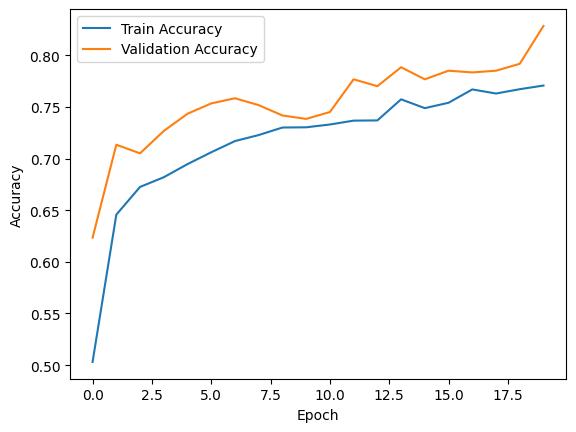

In [ ]:
# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Define class labels (must match dataset folder names)
class_labels = ['glioma', 'menin', 'tumor']  # Adjust if necessary

def preprocess_image(img_path):
    """Load and preprocess an image for prediction."""
    img = image.load_img(img_path, target_size=(64, 64), color_mode='grayscale')  # Load image & resize, force grayscale
    img_array = image.img_to_array(img)  # Convert to numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Expand batch dimension
    img_array = img_array / 255.0  # Normalize (same as during training)
    return img_array

In [ ]:
def predict_images_in_folder(folder_path):
    """Predict the classes of multiple images in a folder."""
    results = []

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # Check if it's an image file
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_array = preprocess_image(img_path)
            prediction = model.predict(img_array)
            predicted_class = np.argmax(prediction)
            results.append((img_name, class_labels[predicted_class]))

    return results

In [ ]:
folder_path = '/content/image'  # Folder containing multiple images
predictions = predict_images_in_folder(folder_path)

# Print results
for img_name, predicted_label in predictions:
    print(f'Image: {img_name} → Predicted Class: {predicted_label}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Image: img2.jpg → Predicted Class: menin
Image: img5.jpg → Predicted Class: tumor
Image: img3.JPG → Predicted Class: menin
Image: img1.jpg → Predicted Class: menin
Image: img4.jpg → Predicted Class: menin
